# Topic model evaluation 

This nb evaluates the topic clusters and their corresponding representations resulting from BERTopic. We compare the topics resulting from the full model which used the fine-tuned sentnece transformer ('Bea-Taylor/objection_fine_tuned_4), to the topics from the baseline model which used the baseline sentence transformer model 'all-MiniLM-L6-v2'. 

I evaluate these models using three metrics:
1. Pairwise cosine similarity of topic representation embeddings (using the relevant sentence transformer). This uses ```from sklearn.metrics.pairwise import cosine_similarity```. 
2. Topic diveristy - which measures the diveristy across all topics produced by the model. This uses the [OCTIS](https://github.com/mind-Lab/octis) package.
3. Topic coherence - which measures the coherence of words in each topic representation. This uses the [OCTIS](https://github.com/mind-Lab/octis) package.

I then directly compare the two topic models by looking at the between model cosine similarity. 

These are some relevant resources: 
- [https://towardsdatascience.com/understanding-topic-coherence-measures-4aa41339634c/](https://towardsdatascience.com/understanding-topic-coherence-measures-4aa41339634c/)
- [https://radimrehurek.com/gensim/models/coherencemodel.html](https://radimrehurek.com/gensim/models/coherencemodel.html)
- Some nice graphs of the model performance: [https://towardsdatascience.com/use-metrics-to-determine-lda-topic-model-size-1a1feaa1ff3c/](https://towardsdatascience.com/use-metrics-to-determine-lda-topic-model-size-1a1feaa1ff3c/)

In [4]:
# Import necessary packages 
import pandas as pd
import numpy as np
import math 

from octis.evaluation_metrics.diversity_metrics import TopicDiversity
from octis.evaluation_metrics.coherence_metrics import Coherence
from sklearn.metrics.pairwise import cosine_similarity

from sentence_transformers import SentenceTransformer

import ast 

import seaborn as sns
import matplotlib.pyplot as plt

from database.comments import Comments
from database.topics import Topics

import sys
sys.path.append('../functions')
from nlp_tasks import NLP_Tasks
nlp_tasks = NLP_Tasks()

Device set to use mps:0
Some weights of the model checkpoint at dslim/bert-base-NER were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use mps:0


Connecting to the ai4ci-db-dev database...
Successfully connected to ai4ci-db-dev.


### The Topic Models 

The topics models were run seperately on a server with higher compute power, and the outputs were then scp-ed locally. 

In this nb I load in the model results saved in folders at: 
- path_to_baseline = '/root/model_outputs/not_tuned_objection/'
- path_to_finetuned = '/root/model_outputs/finetuned_objection/'

Both folders contain:
- object_comments_with_topics.csv
- object_stdout.txt
- object_topic_embeddings.csv
- object_topic_probabilities.csv
- object_topics.csv 

In [9]:
path_to_baseline = '../model_outputs/not_tuned_objection'
path_to_finetuned = '../model_outputs/finetuned_objection'

## Evaluating the full model 

This is the model that used the fine-tuned sentence transformer to generate the embeddings. 

In [24]:
# Load and parse object topics
topics_full_model_object = pd.read_csv(path_to_finetuned+'/object_topics.csv')
object_topics = [ast.literal_eval(item) for item in topics_full_model_object['Representation'].tolist()]
# and the topic embeddings
topics_full_model_object_embeddings = pd.read_csv(path_to_finetuned+'/object_topic_embeddings.csv')

# # Load and parse support topics
# topics_full_model_support = pd.read_csv('/root/comment_crunch/outputs/topic_model/full_bertopic/supports_topics.csv')
# support_topics = [ast.literal_eval(item) for item in topics_full_model_support['Representation'].tolist()]
# # and the topic embeddings
# topics_full_model_support_embeddings = pd.read_csv('/root/comment_crunch/outputs/topic_model/full_bertopic/supports_topic_embeddings.csv')

# # Load and parse neutral topics
# topics_full_model_neutral = pd.read_csv('/root/comment_crunch/outputs/topic_model/full_bertopic/neutral_topics.csv')
# neutral_topics = [ast.literal_eval(item) for item in topics_full_model_neutral['Representation'].tolist()]
# # and the topic embeddings
# topics_full_model_neutral_embeddings = pd.read_csv('/root/comment_crunch/outputs/topic_model/full_bertopic/neutral_topic_embeddings.csv')

In [25]:
print("Number of object topics:", len(object_topics))
# print("Number of support topics:", len(support_topics))
# print("Number of neutral topics:", len(neutral_topics))

# print("Total number of topics:", len(object_topics) + len(support_topics) + len(neutral_topics))

Number of object topics: 100


In [26]:
cs_topics_object = cosine_similarity(topics_full_model_object_embeddings, topics_full_model_object_embeddings)
# cs_topics_support = cosine_similarity(topics_full_model_support_embeddings, topics_full_model_support_embeddings)
# cs_topics_neutral = cosine_similarity(topics_full_model_neutral_embeddings, topics_full_model_neutral_embeddings)

print('Shape of cosine similarity matrix:', cs_topics_object.shape)

Shape of cosine similarity matrix: (100, 100)


In [27]:
print(f'Mean of the cosine similarity of object topics: {np.round(np.mean(cs_topics_object), 4)}')
# print(f'Mean of the cosine similarity of support topics: {np.round(np.mean(cs_topics_support), 4)}')
# print(f'Mean of the cosine similarity of neutral topics: {np.round(np.mean(cs_topics_neutral), 4)}')

Mean of the cosine similarity of object topics: 0.1283


In [28]:
object_pairs = math.comb(len(object_topics), 2)
# support_pairs = math.comb(len(support_topics), 2)
# neutral_pairs = math.comb(len(neutral_topics), 2)

threshold = 0.85

# Calculate the number of pairs above the threshold
object_above_threshold = np.sum(cs_topics_object > threshold)
# the pairs are duplicated
object_above_threshold = object_above_threshold // 2

# support_above_threshold = np.sum(cs_topics_support > threshold)
# support_above_threshold = support_above_threshold // 2

# neutral_above_threshold = np.sum(cs_topics_neutral > threshold)
# neutral_above_threshold = neutral_above_threshold // 2

# percent of the pairs above the threshold
object_percent_above_threshold = (object_above_threshold / object_pairs) * 100
# support_percent_above_threshold = (support_above_threshold / support_pairs) * 100
# neutral_percent_above_threshold = (neutral_above_threshold / neutral_pairs) * 100

print("Object topics above threshold:", object_above_threshold, "(", object_percent_above_threshold, "%)")
# print("Support topics above threshold:", support_above_threshold, "(", support_percent_above_threshold, "%)")
# print("Neutral topics above threshold:", neutral_above_threshold, "(", neutral_percent_above_threshold, "%)")

Object topics above threshold: 52 ( 1.0505050505050506 %)


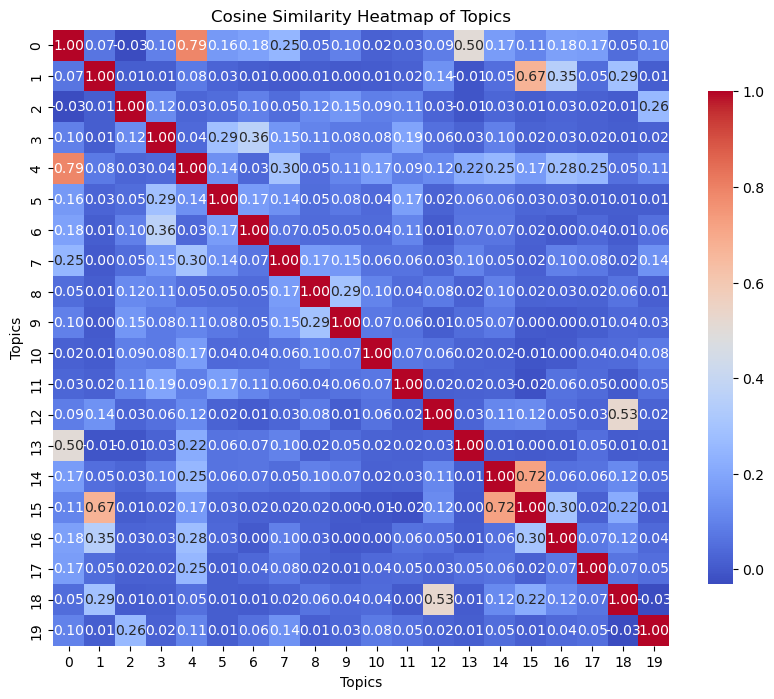

In [29]:
# Compare just the first 20 topics (for visualisation purposes)

cs_topics_object_reduced = cs_topics_object[1:21,1:21]

# plot heatmap of cosine similarity
plt.figure(figsize=(10, 8))
sns.heatmap(cs_topics_object_reduced, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Cosine Similarity Heatmap of Topics')
plt.xlabel('Topics')
plt.ylabel('Topics')
plt.show()

### Scores for the full model (with the fine-tuned sentence transformer)

In [30]:
### TOPIC DIVERSITY 

div_metric= TopicDiversity(topk=3) # Initialize metric

# object
topic_div_score_full_object = div_metric.score({'topics':object_topics})
print(f"Topic Diversity Score (Object): {topic_div_score_full_object}")

# # support
# topic_diversity_score_full_support = div_metric.score({'topics':support_topics})
# print(f"Topic Diversity Score (Support): {topic_diversity_score_full_support}")

# # neutral
# topic_diversity_score_full_neutral = div_metric.score({'topics':neutral_topics})
# print(f"Topic Diversity Score (Neutral): {topic_diversity_score_full_neutral}")

Topic Diversity Score (Object): 0.7266666666666667


In [32]:
### TOPIC COHERENCE

# object
# Initialize coherence metric
coh_metric = Coherence(texts=object_topics, topk=10, measure='c_npmi')  # or 'c_v', etc.
topic_coh_score_full_object = coh_metric.score({'topics': object_topics})
print(f"Topic Coherence Score (object): {topic_coh_score_full_object:.4f}")

# # support
# coh_metric = Coherence(texts=support_topics, topk=10, measure='c_npmi')  # or 'c_v', etc.
# topic_coh_score_full_support = coh_metric.score({'topics': support_topics})
# print(f"Topic Coherence Score (support): {topic_coh_score_full_support:.4f}")   

# # neutral
# coh_metric = Coherence(texts=neutral_topics, topk=10, measure='c_npmi')  # or 'c_v', etc.
# topic_coh_score_full_neutral = coh_metric.score({'topics': neutral_topics})
# print(f"Topic Coherence Score (neutral): {topic_coh_score_full_neutral:.4f}")

Topic Coherence Score (object): 0.6376


### Scores as a function of the number of topics 

In [33]:
# Function to compute diversity score over growing topic sets
def compute_diversity_scores(topic_list, label, metric):
    num_topics = range(1, len(topic_list) + 1)
    scores = []
    for i in range(len(topic_list)):
        partial = topic_list[:i+1]
        score = metric.score({'topics': partial})
        scores.append(score)
    return pd.DataFrame({
        'num_topics': num_topics,
        'diversity_score': scores,
        'topic_type': label
    })

In [34]:
# Compute diversity scores
metric = TopicDiversity(topk=3)

df_object = compute_diversity_scores(object_topics, 'object', metric)
# df_support = compute_diversity_scores(support_topics, 'support', metric)
# df_neutral = compute_diversity_scores(neutral_topics, 'neutral', metric)

# # Combine all into one DataFrame
# df_all = pd.concat([df_object, df_support, df_neutral], ignore_index=True)

In [35]:
diversity_dict = {
    'object': 'orchid',
    # 'support': 'mediumorchid',
    # 'neutral': 'darkorchid'
}

coherence_dict = {
    'object': 'turquoise',
    # 'support': 'lightseagreen',
    # 'neutral': 'teal'
}

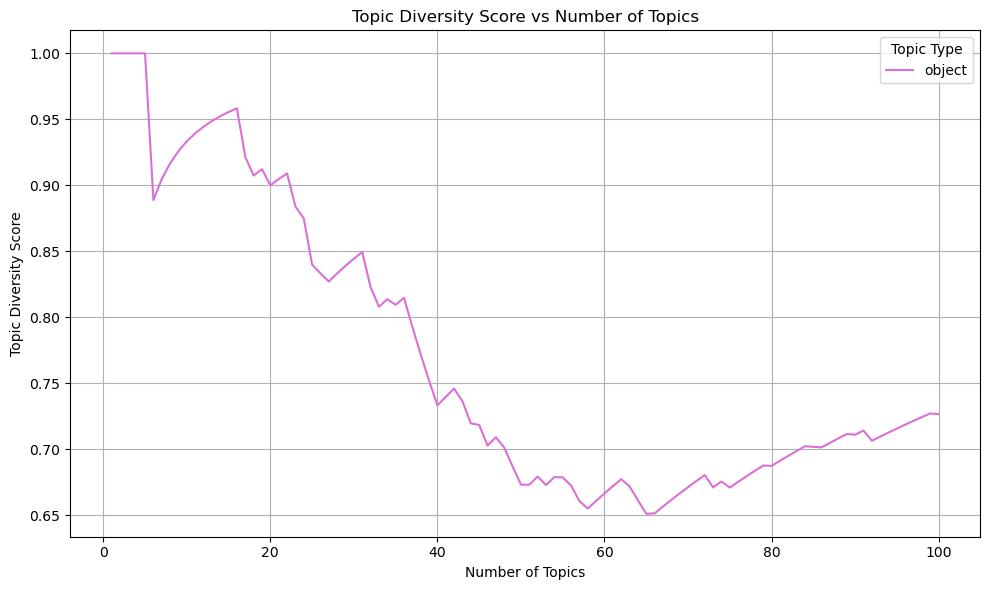

In [36]:
# Plot the diversity scores
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_object, x='num_topics', y='diversity_score', hue='topic_type', palette=diversity_dict)
plt.title('Topic Diversity Score vs Number of Topics')
plt.xlabel('Number of Topics')
plt.ylabel('Topic Diversity Score')
plt.grid(True)
plt.legend(title='Topic Type')
plt.tight_layout()
plt.show()

In [37]:
# function to compute coherence score over growing topic sets
def compute_coherence_scores(topic_list, label, metric):
    num_topics = range(1, len(topic_list) + 1)
    scores = []
    for i in range(len(topic_list)):
        partial = topic_list[:i+1]
        score = metric.score({'topics': partial})
        scores.append(score)
    return pd.DataFrame({
        'num_topics': num_topics,
        'coherence_score': scores,
        'topic_type': label
    })

Note: this currently takes a very long time to run - make sure the GPU is enabled.  

In [38]:
# Compute coherence scores
coh_metric = Coherence(texts=object_topics, topk=5, measure='c_npmi')  # or 'c_v', etc.
df_object_coh = compute_coherence_scores(object_topics, 'object', coh_metric)
# coh_metric = Coherence(texts=support_topics, topk=5, measure='c_npmi')  # or 'c_v', etc.
# df_support_coh = compute_coherence_scores(support_topics, 'support', coh_metric)
# coh_metric = Coherence(texts=neutral_topics, topk=5, measure='c_npmi')  # or 'c_v', etc.
# df_neutral_coh = compute_coherence_scores(neutral_topics, 'neutral', coh_metric)    

# Combine all coherence scores into one DataFrame
# df_all_coh = pd.concat([df_object_coh, df_support_coh, df_neutral_coh], ignore_index=True)

In [ ]:
# df_all_coh.to_csv('/root/comment_crunch/outputs/topic_model/full_bertopic/topic_coherence_scores.csv', index=False)

In [ ]:
# df_all_coh = pd.read_csv('/root/comment_crunch/outputs/topic_model/full_bertopic/topic_coherence_scores.csv')

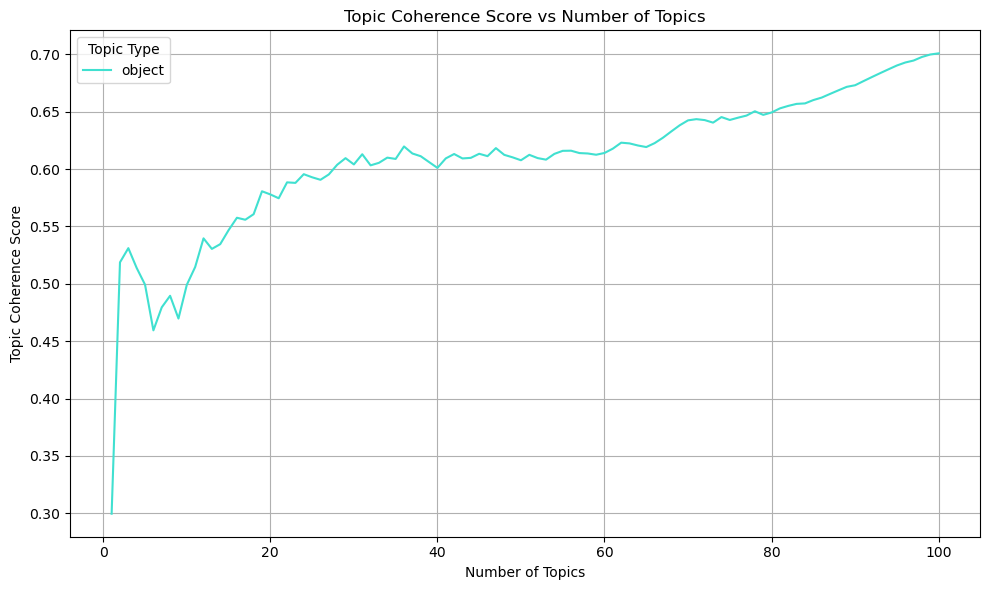

In [39]:
# Plot the coherence scores
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_object_coh, x='num_topics', y='coherence_score', hue='topic_type', palette=coherence_dict)
plt.title('Topic Coherence Score vs Number of Topics')
plt.xlabel('Number of Topics')
plt.ylabel('Topic Coherence Score')
plt.grid(True)
plt.legend(title='Topic Type')
plt.tight_layout()
plt.show()

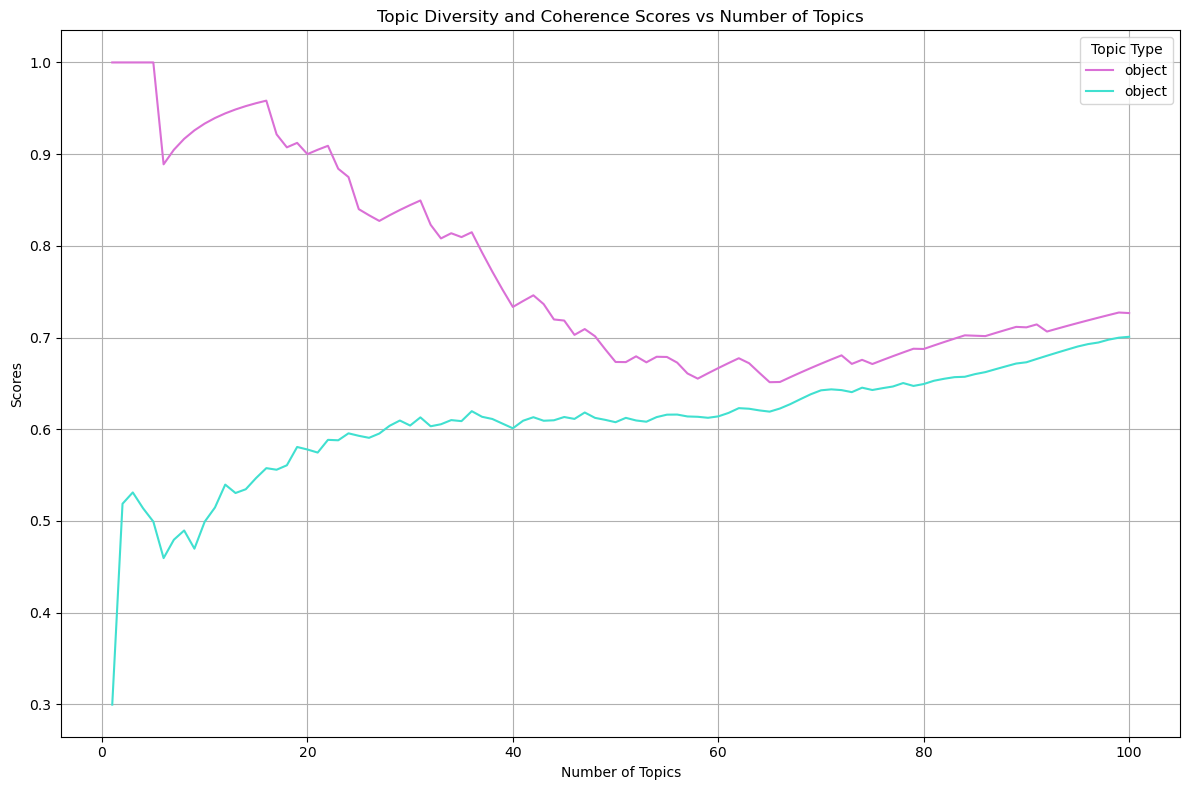

In [40]:
# Plot coherence and diverity scores together
plt.figure(figsize=(12, 8))
diveristy_plot = sns.lineplot(data=df_object, x='num_topics', y='diversity_score', hue='topic_type', style='topic_type', palette=diversity_dict, markers=False, dashes=False)
coherence_plot = sns.lineplot(data=df_object_coh, x='num_topics', y='coherence_score', hue='topic_type', style='topic_type', palette=coherence_dict, markers=False, dashes=True)
plt.title('Topic Diversity and Coherence Scores vs Number of Topics')
plt.xlabel('Number of Topics')
plt.ylabel('Scores')
plt.grid(True)
plt.legend(title='Topic Type')
plt.tight_layout()
plt.show()

## Evaluating the baseline model 
### with embeddings from the baseline sentence transformer model

In [41]:
### TOPIC DIVERSITY 

# object
topics_baseline_model_object = pd.read_csv(path_to_baseline+'/object_topics.csv')
object_topics_baseline = [ast.literal_eval(item) for item in topics_baseline_model_object['Representation'].tolist()]
# and the topic embeddings
topics_baseline_model_object_embeddings = pd.read_csv(path_to_baseline+'/object_topic_embeddings.csv')

# # support
# topics_baseline_model_support = pd.read_csv('/root/comment_crunch/outputs/topic_model/full_bertopic_baseline_st/supports_topics.csv')
# support_topics_baseline = [ast.literal_eval(item) for item in topics_baseline_model_support['Representation'].tolist()]
# # and the topic embeddings
# topics_baseline_model_support_embeddings = pd.read_csv('/root/comment_crunch/outputs/topic_model/full_bertopic_baseline_st/supports_topic_embeddings.csv')

# # neutral
# topics_baseline_model_neutral = pd.read_csv('/root/comment_crunch/outputs/topic_model/full_bertopic_baseline_st/neutral_topics.csv')
# neutral_topics_baseline = [ast.literal_eval(item) for item in topics_baseline_model_neutral['Representation'].tolist()]
# # and the topic embeddings
# topics_baseline_model_neutral_embeddings = pd.read_csv('/root/comment_crunch/outputs/topic_model/full_bertopic_baseline_st/neutral_topic_embeddings.csv')

In [42]:
print("Number of object topics:", len(object_topics_baseline))
# print("Number of support topics:", len(support_topics_baseline))
# print("Number of neutral topics:", len(neutral_topics_baseline))

# print("Total number of topics:", len(object_topics_baseline) + len(support_topics_baseline) + len(neutral_topics_baseline))

Number of object topics: 100


In [43]:
cs_topics_baseline_object = cosine_similarity(topics_baseline_model_object_embeddings, topics_baseline_model_object_embeddings)
# cs_topics_baseline_support = cosine_similarity(topics_baseline_model_support_embeddings, topics_baseline_model_support_embeddings)
# cs_topics_baseline_neutral = cosine_similarity(topics_baseline_model_neutral_embeddings, topics_baseline_model_neutral_embeddings)

print('Shape of cosine similarity matrix:', cs_topics_baseline_object.shape)

Shape of cosine similarity matrix: (100, 100)


In [44]:
print(f'Mean of the cosine similarity of object topics: {np.round(np.mean(cs_topics_baseline_object), 4)}')
# print(f'Mean of the cosine similarity of support topics: {np.round(np.mean(cs_topics_baseline_support), 4)}')
# print(f'Mean of the cosine similarity of neutral topics: {np.round(np.mean(cs_topics_baseline_neutral), 4)}')

Mean of the cosine similarity of object topics: 0.2738


In [45]:
object_baseline_pairs = math.comb(len(object_topics_baseline), 2)
# support_baseline_pairs = math.comb(len(support_topics_baseline), 2)
# neutral_baseline_pairs = math.comb(len(neutral_topics_baseline), 2)

threshold = 0.85

# Calculate the number of pairs above the threshold
object_above_threshold_baseline = np.sum(cs_topics_baseline_object > threshold)
# half of the pairs are counted twice, so we divide by 2
object_above_threshold_baseline = object_above_threshold_baseline // 2

# support_above_threshold_baseline = np.sum(cs_topics_baseline_support > threshold)
# support_above_threshold_baseline = support_above_threshold_baseline // 2

# neutral_above_threshold_baseline = np.sum(cs_topics_baseline_neutral > threshold)
# neutral_above_threshold_baseline = neutral_above_threshold_baseline // 2

# percent of the pairs above the threshold
object_percent_above_threshold_baseline = (object_above_threshold_baseline / object_baseline_pairs) * 100
# support_percent_above_threshold_baseline = (support_above_threshold_baseline / support_baseline_pairs) * 100
# neutral_percent_above_threshold_baseline = (neutral_above_threshold_baseline / neutral_baseline_pairs) * 100

print("Object topics above threshold:", object_above_threshold_baseline, "(", object_percent_above_threshold_baseline, "%)")
# print("Support topics above threshold:", support_above_threshold_baseline, "(", support_percent_above_threshold_baseline, "%)")
# print("Neutral topics above threshold:", neutral_above_threshold_baseline, "(", neutral_percent_above_threshold_baseline, "%)")

Object topics above threshold: 51 ( 1.0303030303030303 %)


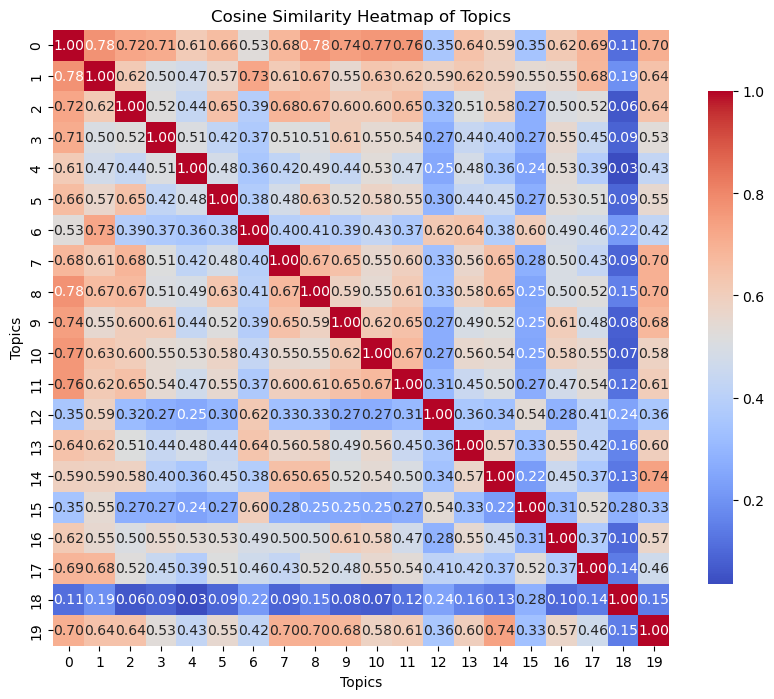

In [46]:
# Compare just the first 20 topics (for visualisation purposes)

cs_topics_reduced_baseline = cs_topics_baseline_object[1:21,1:21]

# plot heatmap of cosine similarity
plt.figure(figsize=(10, 8))
sns.heatmap(cs_topics_reduced_baseline, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Cosine Similarity Heatmap of Topics')
plt.xlabel('Topics')
plt.ylabel('Topics')
plt.show()

In [47]:
# print topics pairs where the cosine similarity is above a certain threshold
# print the actual topic represnetaions from object_topics_baseline

threshold = 0.85
similar_pairs = []
for i in range(len(cs_topics_baseline_object)):
    for j in range(i + 1, len(cs_topics_baseline_object)):
        if cs_topics_baseline_object[i][j] > threshold:
            similar_pairs.append((i, j, cs_topics_baseline_object[i][j], object_topics_baseline[i], object_topics_baseline[j]))

print(f'Number of similar pairs with cosine similarity above {threshold}: {len(similar_pairs)}')

# Print similar pairs
for pair in similar_pairs:
    print(f"Topics {pair[0]} and {pair[1]} have similarity {pair[2]:.2f}")
    print(f"Topic {pair[0]}: {pair[3]}")
    print(f"Topic {pair[1]}: {pair[4]}")
    print("-" * 40)

Number of similar pairs with cosine similarity above 0.85: 1
Topics 0 and 1 have similarity 0.97
Topic 0: ['the', 'and', 'to', 'of', 'is', 'in', 'this', 'will', 'for', 'on']
Topic 1: ['of', 'the', 'and', 'in', 'is', 'area', 'to', 'building', 'be', 'with']
----------------------------------------


In [48]:
metric = TopicDiversity(topk=3) # Initialize metric

# object
topic_div_score_baseline_object = metric.score({'topics':object_topics_baseline})
print(f"Topic Diversity Score for object topics (Baseline): {topic_div_score_baseline_object}")

# # support
# topic_diversity_score_baseline_support = metric.score({'topics':support_topics_baseline})
# print(f"Topic Diversity Score (Support, Baseline): {topic_diversity_score_baseline_support}")

# # neutral
# topic_diversity_score_baseline_neutral = metric.score({'topics':neutral_topics_baseline})
# print(f"Topic Diversity Score (Neutral, Baseline): {topic_diversity_score_baseline_neutral}")

Topic Diversity Score for object topics (Baseline): 0.9166666666666666


In [49]:
### TOPIC COHERENCE

# object
coh_metric = Coherence(texts=object_topics_baseline, topk=10, measure='c_npmi')  # or 'c_v', etc.
topic_coh_score_baseline_object = coh_metric.score({'topics': object_topics_baseline})
print(f"Topic Coherence Score (object, Baseline): {topic_coh_score_baseline_object:.4f}")

# # support
# coh_metric = Coherence(texts=support_topics_baseline, topk=10, measure='c_npmi')  # or 'c_v', etc.
# topic_coh_score_baseline_support = coh_metric.score({'topics': support_topics_baseline})
# print(f"Topic Coherence Score (support, Baseline): {topic_coh_score_baseline_support:.4f}")

# # neutral
# coh_metric = Coherence(texts=neutral_topics_baseline, topk=10, measure='c_npmi')  # or 'c_v', etc.
# topic_coh_score_baseline_neutral = coh_metric.score({'topics': neutral_topics_baseline})
# print(f"Topic Coherence Score (neutral, Baseline): {topic_coh_score_baseline_neutral:.4f}")

Topic Coherence Score (object, Baseline): 0.8562


In [50]:
df_object_baseline = compute_diversity_scores(object_topics_baseline, 'object', metric)
# df_support_baseline = compute_diversity_scores(support_topics_baseline, 'support', metric)
# df_neutral_baseline = compute_diversity_scores(neutral_topics_baseline, 'neutral', metric)

# # Combine all into one DataFrame
# df_all_baseline = pd.concat([df_object_baseline, df_support_baseline, df_neutral_baseline], ignore_index=True)

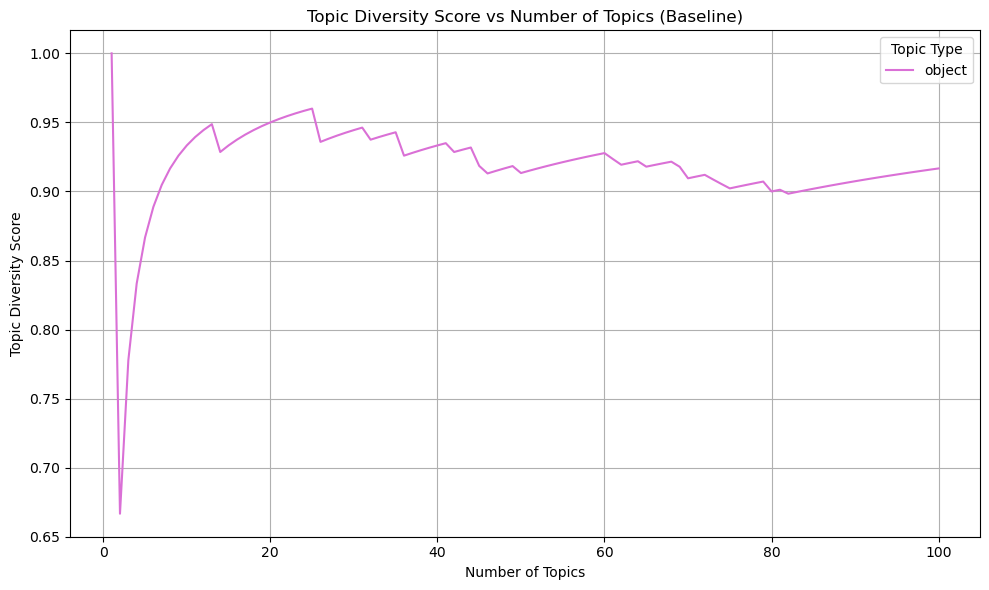

In [52]:
# Plot the diversity scores
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_object_baseline, x='num_topics', y='diversity_score', hue='topic_type', palette=diversity_dict)
plt.title('Topic Diversity Score vs Number of Topics (Baseline)')
plt.xlabel('Number of Topics')
plt.ylabel('Topic Diversity Score')
plt.grid(True)
plt.legend(title='Topic Type')
plt.tight_layout()
plt.show()

Note: this takes a long time to run, so load the saved csv from a previous model run. 

In [53]:
# coherence scores

coh_metric = Coherence(texts=object_topics_baseline, topk=5, measure='c_npmi')  # or 'c_v', etc.
df_object_coh_baseline = compute_coherence_scores(object_topics_baseline, 'object', coh_metric)
# coh_metric = Coherence(texts=support_topics_baseline, topk=5, measure='c_npmi')  # or 'c_v', etc.
# df_support_coh_baseline = compute_coherence_scores(support_topics_baseline, 'support', coh_metric)
# coh_metric = Coherence(texts=neutral_topics_baseline, topk=5, measure='c_npmi')  # or 'c_v', etc.
# df_neutral_coh_baseline = compute_coherence_scores(neutral_topics_baseline, 'neutral', coh_metric)

# Combine all coherence scores into one DataFrame
# df_all_coh_baseline = pd.concat([df_object_coh_baseline, df_support_coh_baseline, df_neutral_coh_baseline], ignore_index=True)

In [ ]:
# df_all_coh_baseline.to_csv('/root/comment_crunch/outputs/topic_model/full_bertopic_baseline_st/topic_coherence_scores.csv', index=False)

In [ ]:
# df_all_coh_baseline = pd.read_csv('/root/comment_crunch/outputs/topic_model/full_bertopic_baseline_st/topic_coherence_scores.csv')

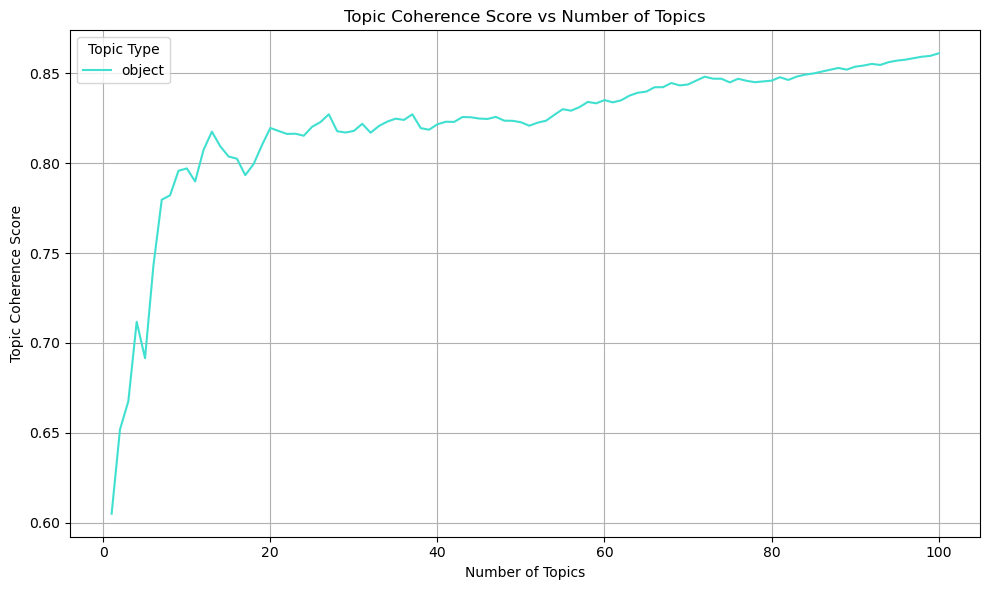

In [54]:
# Plot the coherence scores
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_object_coh_baseline, x='num_topics', y='coherence_score', hue='topic_type', palette=coherence_dict)
plt.title('Topic Coherence Score vs Number of Topics')
plt.xlabel('Number of Topics')
plt.ylabel('Topic Coherence Score')
plt.grid(True)
plt.legend(title='Topic Type')
plt.tight_layout()
plt.show()

# Directly compare the two models 

Now look at the similarity of topics between the two models. This is a bit tricky as currently they use different embeddings. 

In [55]:
model = SentenceTransformer("all-MiniLM-L6-v2")
tokenizer = model.tokenizer

In [56]:
# generate embeddings for the topics
# this step is necessary, as the topics need to be encoded in the same embedding space for comparison 

topics_full_model_object_embeddings = model.encode(object_topics, convert_to_tensor=True)
# topics_full_model_neutral_embeddings = model.encode(neutral_topics, convert_to_tensor=True)
# topics_full_model_support_embeddings = model.encode(support_topics, convert_to_tensor=True)

topics_baseline_model_object_embeddings = model.encode(object_topics_baseline, convert_to_tensor=True)
# topics_baseline_model_neutral_embeddings = model.encode(neutral_topics_baseline, convert_to_tensor=True)
# topics_baseline_model_support_embeddings = model.encode(support_topics_baseline, convert_to_tensor=True)

In [64]:
def count_similar_pairs(threshold, embedding1, embedding2):

    embedding1 = embedding1.cpu()
    embedding2 = embedding2.cpu()

    cosine_similarity_matrix = cosine_similarity(embedding1, embedding2)
    # print(f'Cosine similarity matrix shape: {cosine_similarity_matrix.shape}')

    similar_pairs = []
    for i in range(cosine_similarity_matrix.shape[0]):
        for j in range(i + 1, cosine_similarity_matrix.shape[1]):
            if cosine_similarity_matrix[i][j] > threshold:
                similar_pairs.append((i, j, cosine_similarity_matrix[i][j], object_topics[i], object_topics_baseline[j]))
    print(f'Number of similar pairs with cosine similarity above {threshold}: {len(similar_pairs)}')
    return similar_pairs

In [65]:
similar_object_pairs_075 = count_similar_pairs(0.75, topics_full_model_object_embeddings, topics_baseline_model_object_embeddings)
# similar_neutral_pairs_075 = count_similar_pairs(0.75, topics_full_model_neutral_embeddings, topics_baseline_model_neutral_embeddings)
# similar_support_pairs_075 = count_similar_pairs(0.75, topics_full_model_support_embeddings, topics_baseline_model_support_embeddings)

Number of similar pairs with cosine similarity above 0.75: 5


In [67]:
similar_object_pairs_085 = count_similar_pairs(0.85, topics_full_model_object_embeddings, topics_baseline_model_object_embeddings)
# similar_neutral_pairs_085 = count_similar_pairs(0.85, topics_full_model_neutral_embeddings, topics_baseline_model_neutral_embeddings)
# similar_support_pairs_085 = count_similar_pairs(0.85, topics_full_model_support_embeddings, topics_baseline_model_support_embeddings)

Number of similar pairs with cosine similarity above 0.85: 2


In [68]:
# print similar pairs
for pair in similar_pairs:
    print(f"Topics {pair[0]} and {pair[1]} have similarity {pair[2]:.2f}")
    print(f"Topic {pair[0]}: {pair[3]}")
    print(f"Topic {pair[1]}: {pair[4]}")
    print("-" * 40)

Topics 0 and 1 have similarity 0.97
Topic 0: ['the', 'and', 'to', 'of', 'is', 'in', 'this', 'will', 'for', 'on']
Topic 1: ['of', 'the', 'and', 'in', 'is', 'area', 'to', 'building', 'be', 'with']
----------------------------------------
